<img src="https://s8.hostingkartinok.com/uploads/images/2018/08/308b49fcfbc619d629fe4604bceb67ac.jpg" width=500, height=450>
<h3 style="text-align: center;"><b>Физтех-Школа Прикладной математики и информатики (ФПМИ) МФТИ</b></h3>

---

***Some parts of the notebook are almost the copy of [ mmta-team course](https://github.com/mmta-team/mmta_fall_2020). Special thanks to mmta-team for making them publicly available. [Original notebook](https://github.com/mmta-team/mmta_fall_2020/blob/master/tasks/01_word_embeddings/task_word_embeddings.ipynb).***

<b> Прочитайте семинар, пожалуйста, для успешного выполнения домашнего задания. В конце ноутка напишите свой вывод. Работа без вывода оценивается ниже.

## Задача поиска схожих по смыслу предложений

Мы будем ранжировать вопросы [StackOverflow](https://stackoverflow.com) на основе семантического векторного представления

До этого в курсе не было речи про задачу ранжировния, поэтому введем математическую формулировку

## Задача ранжирования(Learning to Rank)

* $X$ - множество объектов
* $X^l = \{x_1, x_2, ..., x_l\}$ - обучающая выборка
<br>На обучающей выборке задан порядок между некоторыми элементами, то есть нам известно, что некий объект выборки более релевантный для нас, чем другой:
* $i \prec j$ - порядок пары индексов объектов на выборке $X^l$ c индексами $i$ и $j$
### Задача:
построить ранжирующую функцию $a$ : $X \rightarrow R$ такую, что
$$i \prec j \Rightarrow a(x_i) < a(x_j)$$

<img src="https://d25skit2l41vkl.cloudfront.net/wp-content/uploads/2016/12/Featured-Image.jpg" width=500, height=450>

### Embeddings

Будем использовать предобученные векторные представления слов на постах Stack Overflow.<br>
[A word2vec model trained on Stack Overflow posts](https://github.com/vefstathiou/SO_word2vec)

In [1]:
!wget https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1

--2025-09-21 14:40:31--  https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.45.92, 188.185.43.25, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1199620/files/SO_vectors_200.bin [following]
--2025-09-21 14:40:31--  https://zenodo.org/records/1199620/files/SO_vectors_200.bin
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1453905423 (1.4G) [application/octet-stream]
Saving to: ‘SO_vectors_200.bin?download=1’

SO_vectors_200.bin? 100%[===================>]   1.35G  3.86MB/s    in 5m 41s  

2025-09-21 14:46:13 (4.06 MB/s) - ‘SO_vectors_200.bin?download=1’ saved [1453905423/1453905423]



In [1]:
!pip install gensim

In [2]:
from gensim.models.keyedvectors import KeyedVectors
wv_embeddings = KeyedVectors.load_word2vec_format("SO_vectors_200.bin?download=1", binary=True)

#### Как пользоваться этими векторами?

Посмотрим на примере одного слова, что из себя представляет embedding

In [7]:
word = 'dog'
if word in wv_embeddings:
    print(wv_embeddings[word].dtype, wv_embeddings[word].shape, wv_embeddings[word])

float32 (200,) [ 0.6851772  -1.2778991  -0.41913974  1.3623164  -3.1675398   0.09950767
  0.6402681  -1.1245339  -0.6699619  -0.6998852   0.4936771  -0.40500194
 -3.0706816  -2.2809966   0.85798043  2.7093108   0.3492745  -0.03494101
 -0.22330493  1.2290467   1.7755157  -3.158358   -0.6515983   0.7224096
  2.3193083  -1.7969862   0.40903398 -2.744604   -1.7179952  -0.914309
 -0.75887376 -0.35140672 -0.5182776  -1.9097351  -0.8300773   0.02147918
  1.1783471   0.03169126 -0.3069023   1.6666299   0.6711357  -2.1706133
 -0.11800487  0.22336982 -1.2075394  -0.86297905 -0.63865614  1.1733794
  0.10022762  0.7017279   2.7290728  -0.4640484  -2.1719306  -0.3562852
 -1.8449957   0.10270727  1.1125596  -0.8364318   1.9513408  -0.97937447
  1.2650859   0.06809282  0.6477318  -0.52431005 -0.6103959  -2.979829
 -0.7889965  -0.11004248  1.7603841  -1.0547444  -0.98998    -1.1834062
 -2.5359967  -0.35286787  0.7733574   0.16300043  0.76991326  1.9223119
 -1.2843752  -1.5023688   0.15765315 -2.415087

In [6]:
print(f"Num of words: {len(wv_embeddings.index_to_key)}")

Num of words: 1787145


Найдем наиболее близкие слова к слову `dog`:

#### ***Вопрос 1:***
* Входит ли слово `cat` в топ-5 близких слов к слову `dog`? Какое место оно занимает?


In [8]:
import numpy as np
from numpy.linalg import norm

In [14]:
def cosine_sim(v1, v2):
    # v1, v2 (1 x dim)
    return np.array(v1 @ v2.T / norm(v1) / norm(v2))

In [28]:
cosine_sim(wv_embeddings['dog'], wv_embeddings['cats'])

array(0.76212525, dtype=float32)

In [29]:
cosine_sim(wv_embeddings['dog'], wv_embeddings['cat'])

array(0.6852341, dtype=float32)

In [26]:
wv_embeddings.most_similar('dog')

[('animal', 0.8564180135726929),
 ('dogs', 0.7880866527557373),
 ('mammal', 0.7623804211616516),
 ('cats', 0.7621253728866577),
 ('animals', 0.760793924331665),
 ('feline', 0.7392398715019226),
 ('bird', 0.7315488457679749),
 ('animal1', 0.7219215631484985),
 ('doggy', 0.7213349342346191),
 ('labrador', 0.7209131717681885)]

***Ваш ответ:*** 'cat' не входит в топ-5 ближайших слов к 'dog'.

Но входит 'cats'.

### Векторные представления текста

Перейдем от векторных представлений отдельных слов к векторным представлениям вопросов, как к **среднему** векторов всех слов в вопросе. Если для какого-то слова нет предобученного вектора, то его нужно пропустить. Если вопрос не содержит ни одного известного слова, то нужно вернуть нулевой вектор.

In [46]:
import numpy as np
import re
# you can use your tokenizer
# for example, from nltk.tokenize import WordPunctTokenizer
class MyTokenizer:
    def __init__(self):
        pass
    def tokenize(self, text):
        return re.findall('\w+', text)
tokenizer = MyTokenizer()

<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-2760772041.py:9: SyntaxWarning: invalid escape sequence '\w'
  return re.findall('\w+', text)


In [31]:
from nltk.tokenize import WordPunctTokenizer

In [53]:
WPtokenizer = WordPunctTokenizer()

In [47]:
def question_to_vec(question, embeddings, tokenizer, dim=200):
    """
        question: строка
        embeddings: наше векторное представление
        dim: размер любого вектора в нашем представлении

        return: векторное представление для вопроса
    """
    '''your code'''
    # embedding_dim = embeddings.vectors.shape[1]
    features = np.zeros([dim], dtype='float32')

    i = 0
    for word in tokenizer.tokenize(question):
        if word in embeddings:
            features += embeddings[f'{word}']
            i += 1

    return features / i if i != 0 else features


Теперь у нас есть метод для создания векторного представления любого предложения.

#### ***Вопрос 2:***

* Какая третья (с индексом 2) компонента вектора предложения `I love neural networks` (округлите до 2 знаков после запятой)?

In [54]:
# Предложение
question = "I love neural networks"

q_feat = question_to_vec(question, wv_embeddings, WPtokenizer, dim=200)

In [57]:
WPtokenizer.tokenize(question)

['I', 'love', 'neural', 'networks']

In [56]:
q_feat

array([-1.0142275 , -1.6891261 , -1.2854122 , -1.3710302 ,  0.15916634,
        0.06706961,  1.1188413 , -0.07051762,  0.5386369 , -0.37139115,
        0.28913018,  1.03125   , -2.865466  , -1.3192873 ,  2.2098296 ,
        1.1678672 ,  1.0841951 ,  1.8467226 , -0.98733807,  0.8720946 ,
       -0.17219625,  0.73839015, -0.7827826 , -0.8827869 , -0.6152611 ,
       -0.15872358, -0.6170798 ,  0.36668167,  2.0137532 ,  0.2627472 ,
       -1.4950123 , -1.386715  , -1.2049937 , -1.016617  ,  2.7621174 ,
        1.7255713 , -0.19038178, -0.5899447 , -0.1141155 , -1.8890352 ,
       -1.7883505 , -0.20420384, -0.7062034 ,  2.489034  , -0.15452717,
        1.1255013 ,  0.2610835 ,  1.3153247 , -0.57667524, -0.3327141 ,
        1.6764902 ,  0.91229993, -0.69880134,  2.3752553 , -1.7634224 ,
        3.1378052 ,  1.2243204 , -1.0554415 ,  0.7897571 ,  0.04404024,
        1.1623045 , -0.4478023 , -0.9149816 ,  0.01501505, -0.85523087,
       -1.0183454 , -0.7162116 ,  1.0727204 ,  0.8881876 , -0.29

Третья (с индексом 2) компонента вектора предложения `I love neural networks`: **-1.29**

### Оценка близости текстов

Представим, что мы используем идеальные векторные представления слов. Тогда косинусное расстояние между дублирующими предложениями должно быть меньше, чем между случайно взятыми предложениями.

Сгенерируем для каждого из $N$ вопросов $R$ случайных отрицательных примеров и примешаем к ним также настоящие дубликаты. Для каждого вопроса будем ранжировать с помощью нашей модели $R + 1$ примеров и смотреть на позицию дубликата. Мы хотим, чтобы дубликат был первым в ранжированном списке.

#### Hits@K
Первой простой метрикой будет количество корректных попаданий для какого-то $K$:
$$ \text{Hits@K} = \frac{1}{N}\sum_{i=1}^N \, [rank\_q_i^{'} \le K],$$
* $\begin{equation*}
[x < 0 ] \equiv
 \begin{cases}
   1, &x < 0\\
   0, &x \geq 0
 \end{cases}
\end{equation*}$ - индикаторная функция
* $q_i$ - $i$-ый вопрос
* $q_i^{'}$ - его дубликат
* $rank\_q_i^{'}$ - позиция дубликата в ранжированном списке ближайших предложений для вопроса $q_i$.

Hits@K  измеряет долю вопросов, для которых правильный ответ попал в топ-K позиций среди отранжированных кандидатов.

#### DCG@K
Второй метрикой будет упрощенная DCG метрика, учитывающая порядок элементов в списке путем домножения релевантности элемента на вес равный обратному логарифму номера позиции::
$$ \text{DCG@K} = \frac{1}{N} \sum_{i=1}^N\frac{1}{\log_2(1+rank\_q_i^{'})}\cdot[rank\_q_i^{'} \le K],$$
С такой метрикой модель штрафуется за большой ранк корректного ответа.

DCG@K  измеряет качество ранжирования, учитывая не только факт наличия правильного ответа в топ-K, но и ***его точную позицию***.

<img src='https://hsto.org/files/1c5/edf/dee/1c5edfdeebce4b71a86bdf986d9f88f2.jpg' width=400, height=200>

#### Пример оценок

Вычислим описанные выше метрики для игрушечного примера.
Пусть
* $N = 1$, $R = 3$
* <font color='green'>"Что такое python?"</font> - вопрос $q_1$
* <font color='red'>"Что такое язык python?"</font> - его дубликат $q_i^{'}$

Пусть модель выдала следующий ранжированный список кандидатов:

1. "Как изучить с++?"
2. <font color='red'>"Что такое язык python?"</font>
3. "Хочу учить Java"
4. "Не понимаю Tensorflow"

$\Rightarrow rank\_q_i^{'} = 2$

Вычислим метрику *Hits@K* для *K = 1, 4*:

- [K = 1] $\text{Hits@1} =  [rank\_q_i^{'} \le 1]$

Проверяем условие $ \text{rank}_{q'_1} \leq 1 $: ***условие неверно***.

Следовательно, $[\text{rank}_{q'_1} \leq 1] = 0$.

- [K = 4] $\text{Hits@4} =  [rank\_q_i^{'} \le 4] = 1$

Проверяем условие $ \text{rank}_{q'_1} \leq 4 $: ***условие верно***.

Вычислим метрику *DCG@K* для *K = 1, 4*:
- [K = 1] $\text{DCG@1} = \frac{1}{\log_2(1+2)}\cdot[2 \le 1] = 0$
- [K = 4] $\text{DCG@4} = \frac{1}{\log_2(1+2)}\cdot[2 \le 4] = \frac{1}{\log_2{3}}$

#### ***Вопрос 3***:
* Вычислите `DCG@10`, если $rank\_q_i^{'} = 9$(округлите до одного знака после запятой)



In [65]:
print(f'DCG@10 = {round(1 / np.log2(10), 1)}')

DCG@10 = 0.3


#### Более сложный пример оценок

Рассмотрим пример с $ N > 1 $, где $ N = 3 $ (три вопроса) и для каждого вопроса заданы позиции их дубликатов. Вычислим метрики **Hits@K** для разных значений $ K $.

---

- $ N = 3 $: Три вопроса ($ q_1, q_2, q_3 $).
- Для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):
  - $ \text{rank}_{q'_1} = 2 $,
  - $ \text{rank}_{q'_2} = 5 $,
  - $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **Hits@K** для $ K = 1, 5 $.

---

**Для $ K = 1 $:**

Подставим значения:
$$
\text{Hits@1} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 1] + [\text{rank}_{q'_2} \leq 1] + [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{Hits@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$

$$
\boxed{\text{Hits@1} = \frac{1}{3}}.
$$

---

**Для $ K = 5 $:**

Подставим значения:
$$
\text{Hits@5} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 5] + [\text{rank}_{q'_2} \leq 5] + [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{Hits@5} = \frac{1}{3} \cdot (1 + 1 + 1) = 1.
$$

$$
\boxed{\text{Hits@5} = 1}.
$$

Теперь вычислим метрику **DCG@K** для того же примера, где $ N = 3 $ (три вопроса), и для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):

- $ \text{rank}_{q'_1} = 2 $,
- $ \text{rank}_{q'_2} = 5 $,
- $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **DCG@K** для $ K = 1, 5 $.

---
**Для $ K = 1 $:**
Подставим значения:
$$
\text{DCG@1} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{DCG@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$
$$
\boxed{\text{DCG@1} = \frac{1}{3}}.
$$

---


**Для $ K = 5 $:**
Подставим значения:
$$
\text{DCG@5} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{DCG@5} = \frac{1}{3} \cdot (0.631 + 0.387 + 1) = \frac{1}{3} \cdot 2.018 \approx 0.673.
$$

$$
\boxed{\text{DCG@5} \approx 0.673}.
$$

#### ***Вопрос 4:***
* Найдите максимум `Hits@47 - DCG@1`?



Максимум Hits@47 - DCG@1 равен 1. Это произойдет в том случае, если релевантный пример будет на позиции в диапазоне [2, 47]. Тогда Hits@47 = 1, а DCG@1 = 0

### HITS\_COUNT и DCG\_SCORE

Каждая функция имеет два аргумента: $dup\_ranks$ и $k$.

$dup\_ranks$ является списком, который содержит рейтинги дубликатов (их позиции в ранжированном списке).

К примеру для <font color='red'>"Что такое язык python?"</font> $dup\_ranks = [2]$.

In [66]:
def hits_count(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть Hits@k
    """
    # Подсчитываем количество дубликатов, чей ранг <= k
    '''your code'''
    hits_value = 0
    for rank in dup_ranks:
        if rank <= k:
            hits_value += 1
    return hits_value / len(dup_ranks)

In [70]:
dup_ranks = [1, 2, 3, 5]

k = 1
hits_value = hits_count(dup_ranks, k)
print(f"Hits@1 = {hits_value}")

k = 4
hits_value = hits_count(dup_ranks, k)
print(f"Hits@4 = {hits_value}")

Hits@1 = 0.25
Hits@4 = 0.75


In [71]:
import math

def dcg_score(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть DCG@k
    """
    # Вычисляем сумму для всех релевантных дубликатов
    dcg_value = 0
    for rank in dup_ranks:
        if rank <= k :
            dcg_value += 1 / np.log2(1+rank)

    # Делим на общее количество вопросов
    '''your code'''
    return dcg_value / len(dup_ranks)

In [73]:
# Пример списка позиций дубликатов
dup_ranks = [1, 2, 4]

# Вычисляем DCG@1
dcg_value = dcg_score(dup_ranks, k=1)
print(f"DCG@1 = {dcg_value:.3f}")

# Вычисляем DCG@4
dcg_value = dcg_score(dup_ranks, k=4)
print(f"DCG@10 = {dcg_value:.3f}")

DCG@1 = 0.333
DCG@10 = 0.687


Протестируем функции. Пусть $N = 1$, то есть один эксперимент. Будем искать копию вопроса и оценивать метрики.

In [74]:
import pandas as pd

In [76]:
copy_answers = ["How does the catch keyword determine the type of exception that was thrown",]

# наши кандидаты
candidates_ranking = [["How Can I Make These Links Rotate in PHP",
                       "How does the catch keyword determine the type of exception that was thrown",
                       "NSLog array description not memory address",
                       "PECL_HTTP not recognised php ubuntu"],]

# dup_ranks — позиции наших копий, так как эксперимент один, то этот массив длины 1
dup_ranks = [2] # веду счет кандидатов не с 0, а с 1, тк это именно позиции, а не индексы

# вычисляем метрику для разных k
print('Ваш ответ HIT:', [hits_count(dup_ranks, k) for k in range(1, 5)])
print('Ваш ответ DCG:', [round(dcg_score(dup_ranks, k), 5) for k in range(1, 5)])

Ваш ответ HIT: [0.0, 1.0, 1.0, 1.0]
Ваш ответ DCG: [0.0, 0.63093, 0.63093, 0.63093]


У вас должно получиться

In [77]:
# correct_answers - метрика для разных k
correct_answers = pd.DataFrame([[0, 1, 1, 1], [0, 1 / (np.log2(3)), 1 / (np.log2(3)), 1 / (np.log2(3))]],
                               index=['HITS', 'DCG'], columns=range(1,5))
correct_answers

,1,2,3,4
HITS,0,1.00000,1.00000,1.00000
DCG,0,0.63093,0.63093,0.63093


### Данные
[arxiv link](https://drive.google.com/file/d/1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_/edit)

`train.tsv` - выборка для обучения.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>**

`validation.tsv` - тестовая выборка.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>, <отрицательный пример 1>, <отрицательный пример 2>, ...**

In [81]:
!unzip stackoverflow_similar_questions.zip

Archive:  stackoverflow_similar_questions.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of stackoverflow_similar_questions.zip or
        stackoverflow_similar_questions.zip.zip, and cannot find stackoverflow_similar_questions.zip.ZIP, period.


Считайте данные.

In [85]:
!file stackoverflow_similar_questions.zip

stackoverflow_similar_questions.zip: Zip archive data, at least v1.0 to extract, compression method=store


In [86]:
!unzip -o stackoverflow_similar_questions.zip

Archive:  stackoverflow_similar_questions.zip
   creating: data/
  inflating: data/.DS_Store          
   creating: __MACOSX/
   creating: __MACOSX/data/
  inflating: __MACOSX/data/._.DS_Store  
  inflating: data/train.tsv          
  inflating: data/validation.tsv     


In [87]:
def read_corpus(filename):
    data = []
    with open(filename, encoding='utf-8') as file:
        for line in file:
            data.append(line.strip().split('\t'))
    return data

Нам понадобиться только файл validation.

In [88]:
validation_data = read_corpus('./data/validation.tsv')

Кол-во строк

In [89]:
len(validation_data)

3760

Размер нескольких первых строк

In [90]:
for i in range(25):
    print(i + 1, len(validation_data[i]))

1 1001
2 1001
3 1001
4 1001
5 1001
6 1001
7 1001
8 1001
9 1001
10 1001
11 1001
12 1001
13 1001
14 1001
15 1001
16 1001
17 1001
18 1001
19 1001
20 1001
21 1001
22 1001
23 1001
24 1001
25 1001


In [93]:
validation_data[5][:5]

['Flex collision testing with hitTestObject',
 'How can I test if a Flex control is obscured by another?',
 'How to use DI with WinRT',
 'Modify address in Django middleware',
 'Is it possible to programmatically change the default search engine for the Iphone?']

### Ранжирование без обучения

Реализуйте функцию ранжирования кандидатов на основе косинусного расстояния. Функция должна по списку кандидатов вернуть отсортированный список пар (позиция в исходном списке кандидатов, кандидат). При этом позиция кандидата в полученном списке является его рейтингом (первый - лучший). Например, если исходный список кандидатов был [a, b, c], и самый похожий на исходный вопрос среди них - c, затем a, и в конце b, то функция должна вернуть список **[(2, c), (0, a), (1, b)]**.

In [94]:
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy

In [98]:
def rank_candidates(question, candidates, embeddings, tokenizer, dim=200):
    """
        question: строка
        candidates: массив строк(кандидатов) [a, b, c]
        result: пары (начальная позиция, кандидат) [(2, c), (0, a), (1, b)]
    """
    '''your code'''
    result = []

    question_vec = question_to_vec(question, embeddings, tokenizer, dim)
    for i, candidate in enumerate(candidates):
        cand_vec = question_to_vec(candidate, embeddings, tokenizer, dim)
        result.append((i, candidate, cosine_sim(question_vec, cand_vec))) # использовал функцию косинусной схожести из начала дз

    result.sort(key=lambda x: x[2], reverse=True)

    return [(idx, cand) for idx, cand, sim in result]

Протестируйте работу функции на примерах ниже. Пусть $N=2$, то есть два эксперимента

In [99]:
questions = ['converting string to list', 'Sending array via Ajax fails']

candidates = [['Convert Google results object (pure js) to Python object', # первый эксперимент
               'C# create cookie from string and send it',
               'How to use jQuery AJAX for an outside domain?'],

              ['Getting all list items of an unordered list in PHP',      # второй эксперимент
               'WPF- How to update the changes in list item of a list',
               'select2 not displaying search results']]

In [100]:
for question, q_candidates in zip(questions, candidates):
        ranks = rank_candidates(question, q_candidates, wv_embeddings, tokenizer)
        print(ranks)
        print()

[(1, 'C# create cookie from string and send it'), (0, 'Convert Google results object (pure js) to Python object'), (2, 'How to use jQuery AJAX for an outside domain?')]

[(1, 'WPF- How to update the changes in list item of a list'), (0, 'Getting all list items of an unordered list in PHP'), (2, 'select2 not displaying search results')]



Для первого экперимента вы можете полностью сравнить ваши ответы и правильные ответы. Но для второго эксперимента два ответа на кандидаты будут <b>скрыты</b>(*)

In [ ]:
# должно вывести
results = [[(1, 'C# create cookie from string and send it'),
            (0, 'Convert Google results object (pure js) to Python object'),
            (2, 'How to use jQuery AJAX for an outside domain?')],
           [(*, 'Getting all list items of an unordered list in PHP'), #скрыт
            (*, 'select2 not displaying search results'), #скрыт
            (*, 'WPF- How to update the changes in list item of a list')]] #скрыт

Последовательность начальных индексов вы должны получить `для эксперимента 1`  1, 0, 2.

#### ***Вопрос 5:***
* Какую последовательность начальных индексов вы получили `для эксперимента 2`(перечисление без запятой и пробелов, например, `102` для первого эксперимента?


102

Теперь мы можем оценить качество нашего метода. Запустите следующие два блока кода для получения результата. Обратите внимание, что вычисление расстояния между векторами занимает некоторое время (примерно 10 минут). Можете взять для validation 1000 примеров.

In [101]:
from tqdm.notebook import tqdm

In [102]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, wv_embeddings, tokenizer)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

/tmp/ipython-input-461196727.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.array(v1 @ v2.T / norm(v1) / norm(v2))


In [103]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.463 | Hits@   1: 0.463
DCG@   5: 0.539 | Hits@   5: 0.609
DCG@  10: 0.571 | Hits@  10: 0.708
DCG@ 100: 0.633 | Hits@ 100: 0.997
DCG@ 500: 0.633 | Hits@ 500: 1.000
DCG@1000: 0.633 | Hits@1000: 1.000


Из формул выше можно понять, что

- $ \text{Hits@K} $ **монотонно неубывающая функция** $ K $, которая стремится к 1 при $ K \to \infty $.

- $ \text{DCG@K} $ **монотонно неубывающая функция** $ K $, но рост замедляется с увеличением $ K $ из-за убывания веса $ \frac{1}{\log_2(1 + \text{rank}_{q'_i})} $.

### Эмбеддинги, обученные на корпусе похожих вопросов

In [104]:
train_data = read_corpus('./data/train.tsv')

Улучшите качество модели.<br>Склеим вопросы в пары и обучим на них модель Word2Vec из gensim. Выберите размер window. Объясните свой выбор.

***Рассмотрим подробнее*** данное склеивание.

1. Каждая строка из train_data разбивается на вопрос (question) и список кандидатов.

2. Для каждого кандидата вопрос склеивается с ним в одну строку.

3. Склеенная строка (combined_text) токенизируется, и полученный список токенов добавляется в общий корпус (corpus).

***Пример***

    Вопрос: "What is Python?"
    Кандидаты: ["Python is a programming language", "Java is another language"]
    Склеенные строки:
        "What is Python? Python is a programming language"
        "What is Python? Java is another language"
         
    Токенизированные списки:
        ['what', 'is', 'python', 'python', 'is', 'a', 'programming', 'language']
        ['what', 'is', 'python', 'java', 'is', 'another', 'language']
         
     

In [107]:
train_data[1]

['Which HTML 5 Canvas Javascript to use for making an interactive drawing tool?',
 'Event handling for geometries in Three.js?']

In [106]:
train_data[111259]

['How to remove special characters from a string?',
 'Json encode not able to fetch special characters from db in php']

In [110]:
# Создаем общий корпус текстов
corpus = []

'''your code'''
for train in train_data:
    combined_text = train[0] + train[1]
    corpus.append(tokenizer.tokenize(combined_text))

In [111]:
len(corpus)

1000000

## Эксперименты

### window=10, min_count=5, tokenizer=custom

In [112]:
from gensim.models import Word2Vec
embeddings_trained = Word2Vec(
    sentences=corpus,        # Корпус токенизированных текстов
    vector_size=200,         # Размерность векторов
    window=10,                # Размер окна контекста
    min_count=5,             # Минимальная частота слов
    workers=4                # Количество потоков
).wv

In [128]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained, tokenizer)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

/tmp/ipython-input-461196727.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.array(v1 @ v2.T / norm(v1) / norm(v2))


In [118]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.279 | Hits@   1: 0.279
DCG@   5: 0.343 | Hits@   5: 0.400
DCG@  10: 0.361 | Hits@  10: 0.459
DCG@ 100: 0.416 | Hits@ 100: 0.727
DCG@ 500: 0.442 | Hits@ 500: 0.926
DCG@1000: 0.450 | Hits@1000: 1.000


### window=8, min_count=3, tokenizer=custom

In [115]:
embeddings_trained_2 = Word2Vec(
    sentences=corpus,        # Корпус токенизированных текстов
    vector_size=200,         # Размерность векторов
    window=8,                # Размер окна контекста
    min_count=3,             # Минимальная частота слов
    workers=4                # Количество потоков
).wv

In [122]:
wv_ranking_2 = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained_2, tokenizer)
    wv_ranking_2.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

/tmp/ipython-input-461196727.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.array(v1 @ v2.T / norm(v1) / norm(v2))


In [123]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking_2, k), k, hits_count(wv_ranking_2, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.265 | Hits@   1: 0.265
DCG@   5: 0.333 | Hits@   5: 0.392
DCG@  10: 0.352 | Hits@  10: 0.453
DCG@ 100: 0.408 | Hits@ 100: 0.727
DCG@ 500: 0.434 | Hits@ 500: 0.930
DCG@1000: 0.442 | Hits@1000: 1.000


### window=10, min_count=5, tokenizer=WPtokenizer

In [124]:
wv_ranking_3 = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained, WPtokenizer)
    wv_ranking_3.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

/tmp/ipython-input-461196727.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.array(v1 @ v2.T / norm(v1) / norm(v2))


In [125]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking_3, k), k, hits_count(wv_ranking_3, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.279 | Hits@   1: 0.279
DCG@   5: 0.343 | Hits@   5: 0.400
DCG@  10: 0.361 | Hits@  10: 0.459
DCG@ 100: 0.416 | Hits@ 100: 0.727
DCG@ 500: 0.442 | Hits@ 500: 0.926
DCG@1000: 0.450 | Hits@1000: 1.000


### window=8, min_count=3, tokenizer=WPtokenizer

In [126]:
wv_ranking_4 = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained_2, WPtokenizer)
    wv_ranking_4.append([r[0] for r in ranks].index(0) + 1)

  0%|          | 0/3760 [00:00<?, ?it/s]

/tmp/ipython-input-461196727.py:3: RuntimeWarning: invalid value encountered in scalar divide
  return np.array(v1 @ v2.T / norm(v1) / norm(v2))


In [127]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking_4, k), k, hits_count(wv_ranking_4, k)))

  0%|          | 0/6 [00:00<?, ?it/s]

DCG@   1: 0.265 | Hits@   1: 0.265
DCG@   5: 0.333 | Hits@   5: 0.392
DCG@  10: 0.352 | Hits@  10: 0.453
DCG@ 100: 0.408 | Hits@ 100: 0.727
DCG@ 500: 0.434 | Hits@ 500: 0.930
DCG@1000: 0.442 | Hits@1000: 1.000


### Замечание:
Решить эту задачу с помощью обучения полноценной нейронной сети будет вам предложено, как часть задания в одной из домашних работ по теме "Диалоговые системы".

Напишите свой вывод о полученных результатах.
* Какой принцип токенизации даёт качество лучше и почему?
* Помогает ли нормализация слов?
* Какие эмбеддинги лучше справляются с задачей и почему?
* Почему получилось плохое качество решения задачи?
* Предложите свой подход к решению задачи.

## Вывод:


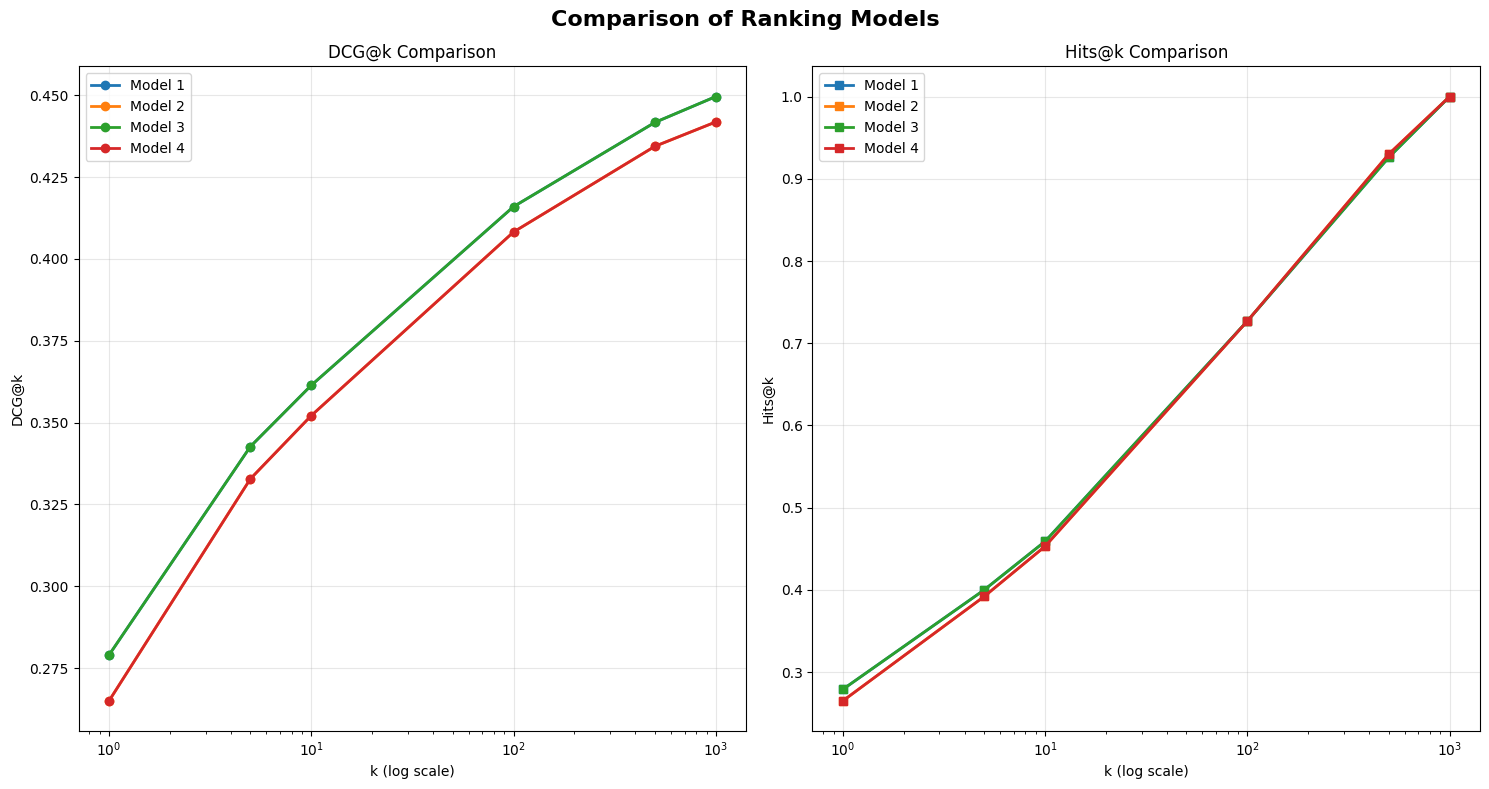

In [134]:
import matplotlib.pyplot as plt

rankings = {
    'Model 1': wv_ranking,
    'Model 2': wv_ranking_2,
    'Model 3': wv_ranking_3,
    'Model 4': wv_ranking_4
}

k_values = [1, 5, 10, 100, 500, 1000]

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Comparison of Ranking Models', fontsize=16, fontweight='bold')

# 1. График DCG@k
ax1 = axes[0]
for model_name, ranking in rankings.items():
    dcg_scores = [dcg_score(ranking, k) for k in k_values]
    ax1.plot(k_values, dcg_scores, marker='o', label=model_name, linewidth=2)

ax1.set_xscale('log')
ax1.set_xlabel('k (log scale)')
ax1.set_ylabel('DCG@k')
ax1.set_title('DCG@k Comparison')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. График Hits@k
ax2 = axes[1]
for model_name, ranking in rankings.items():
    hits_scores = [hits_count(ranking, k) for k in k_values]
    ax2.plot(k_values, hits_scores, marker='s', label=model_name, linewidth=2)

ax2.set_xscale('log')
ax2.set_xlabel('k (log scale)')
ax2.set_ylabel('Hits@k')
ax2.set_title('Hits@k Comparison')
ax2.grid(True, alpha=0.3)
ax2.legend()


plt.tight_layout()
plt.show()

Значения на предобученных эмбеддингах были:

DCG@   1: 0.463 | Hits@   1: 0.463

DCG@   5: 0.539 | Hits@   5: 0.609

DCG@  10: 0.571 | Hits@  10: 0.708

DCG@ 100: 0.633 | Hits@ 100: 0.997

DCG@ 500: 0.633 | Hits@ 500: 1.000

DCG@1000: 0.633 | Hits@1000: 1.000

***Выводы***

Кастомная токенизация и WordPunktTokenizer не показали разницы на данной задаче. Хотя можно было бы побольше поиграть классом, но особо не вижу смысла. Уверен, что готовые токенайзеры хорошо справляются.

Парамтры window=10, min_count=5 показали себя немного лучше, чем window=8, min_count=3 на DCG.

Предобученные эмбеддинги показали значительно лучший результат. Причиной может быть короткий контекст при слиянии двух вопросов. А также ускоспециализированные технические вопросы.